# House 4 — Recurrent SNN Energy Forecasting

RSNN experiment for next 15-minute aggregate power forecasting using REFIT House 4.

**Setup**
- 15-minute resampling and a 24-step input window
- Aggregate, appliance channels, cyclical time features, and aggregate rate-of-change
- Raw Watt targets standardized using training data only
- Recurrent LIF hidden state with continuous membrane readout
- No skip connection
- Fixed training-set peak weighting plus one-step derivative matching loss
- AdamW with early stopping
- Final metrics reported in Watts, including peak diagnostics


In [1]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [ ]:
DATA_PATH = "/home/ahaandesai/Dev/FYP/data/House_4.csv"
WINDOW = 24
HORIZON = 1
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
HIDDEN_SIZE = 32
BETA = 0.9
PATIENCE = 7

print("Window:", WINDOW)
print("Horizon:", HORIZON)
print("Learning rate:", LEARNING_RATE)


Window: 24
Horizon: 1
Learning rate: 0.0001


In [9]:
df = pd.read_csv(DATA_PATH)
df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time").reset_index(drop=True)

power_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9"
]

df = (
    df[["Time"] + power_cols]
    .set_index("Time")
    .resample("15min")
    .mean()
    .dropna()
    .reset_index()
)

hour = df["Time"].dt.hour + df["Time"].dt.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["agg_diff"] = df["Aggregate"].diff().fillna(0)
df["Target"] = df["Aggregate"].shift(-HORIZON)
df = df.dropna().reset_index(drop=True)

n = len(df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("15-minute shape:", df.shape)
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


15-minute shape: (53374, 15)
Train: (37361, 15)
Val:   (8006, 15)
Test:  (8007, 15)


In [10]:
power_scaler = StandardScaler()
train_power_scaled = power_scaler.fit_transform(train_df[power_cols])
val_power_scaled = power_scaler.transform(val_df[power_cols])
test_power_scaled = power_scaler.transform(test_df[power_cols])

diff_scaler = StandardScaler()
train_df["agg_diff_scaled"] = diff_scaler.fit_transform(train_df[["agg_diff"]]).ravel()
val_df["agg_diff_scaled"] = diff_scaler.transform(val_df[["agg_diff"]]).ravel()
test_df["agg_diff_scaled"] = diff_scaler.transform(test_df[["agg_diff"]]).ravel()

# Raw-Watt target scaling: no log transformation.
target_scaler = StandardScaler()
target_scaler.fit(train_df[["Target"]])

feature_cols = power_cols + ["hour_sin", "hour_cos", "agg_diff_scaled"]

def create_sequences(power_scaled, df_split, window=WINDOW):
    X = []
    y = []
    previous_y = []
    target_scaled = target_scaler.transform(df_split[["Target"]]).ravel()

    for i in range(len(power_scaled) - window):
        sequence = np.column_stack([
            power_scaled[i:i + window],
            df_split["hour_sin"].values[i:i + window],
            df_split["hour_cos"].values[i:i + window],
            df_split["agg_diff_scaled"].values[i:i + window]
        ])
        X.append(sequence)
        previous_y.append(target_scaled[i + window - 1])
        y.append(target_scaled[i + window])

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1),
        np.asarray(previous_y, dtype=np.float32).reshape(-1, 1)
    )

X_train, y_train, previous_y_train = create_sequences(train_power_scaled, train_df)
X_val, y_val, previous_y_val = create_sequences(val_power_scaled, val_df)
X_test, y_test, previous_y_test = create_sequences(test_power_scaled, test_df)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)


X_train: (37337, 24, 13)
X_val:   (7982, 24, 13)
X_test:  (7983, 24, 13)


In [11]:
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train),
        torch.tensor(previous_y_train)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val),
        torch.tensor(y_val),
        torch.tensor(previous_y_val)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test),
        torch.tensor(previous_y_test)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 292
Validation batches: 63
Test batches: 63


In [18]:
class PeakWeightedLoss(nn.Module):
    def __init__(self, peak_threshold, alpha=5.0, beta=0.5):
        super().__init__()
        self.peak_threshold = peak_threshold
        self.alpha = alpha
        self.beta = beta
        self.base_mse = nn.MSELoss(reduction="none")

    def forward(self, pred, target, previous_target):
        elemental_loss = self.base_mse(pred, target)
        under_predicting_peak = (target > pred) & (target >= self.peak_threshold)
        weights = torch.where(
            under_predicting_peak,
            torch.full_like(target, self.alpha),
            torch.ones_like(target)
        )
        weighted_loss = (elemental_loss * weights).mean()

        predicted_change = pred - previous_target
        target_change = target - previous_target
        derivative_loss = nn.functional.mse_loss(
            predicted_change,
            target_change
        )
        return weighted_loss + self.beta * derivative_loss


peak_threshold = np.quantile(y_train, 0.85)
criterion = PeakWeightedLoss(
    peak_threshold=torch.tensor(peak_threshold, dtype=torch.float32, device=DEVICE),
    alpha=5.0,
    beta=0.5
)
print("Fixed standardized peak threshold:", peak_threshold)
print("Peak under-prediction weight:", criterion.alpha)


Fixed standardized peak threshold: 0.46007144
Peak under-prediction weight: 5.0


In [15]:
class RSNNForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32, beta=0.9, pool_mix=0.5):
        super().__init__()
        self.input_layer = nn.Linear(input_size, hidden_size)
        self.recurrent_lif = snn.RLeaky(
            beta=beta,
            linear_features=hidden_size,
            spike_grad=surrogate.fast_sigmoid()
        )
        self.attention = nn.Linear(hidden_size, 1)
        self.output_layer = nn.Linear(hidden_size, 1)
        self.pool_mix = pool_mix

    def forward(self, x):
        spikes, membrane = self.recurrent_lif.init_rleaky()
        membrane_states = []

        for t in range(x.size(1)):
            current = self.input_layer(x[:, t, :])
            spikes, membrane = self.recurrent_lif(
                current,
                spikes,
                membrane
            )
            membrane_states.append(membrane)

        states = torch.stack(membrane_states, dim=1)
        max_membrane = states.max(dim=1).values
        attention_scores = self.attention(states).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)
        attention_membrane = torch.sum(
            states * attention_weights.unsqueeze(-1),
            dim=1
        )
        pooled_membrane = (
            self.pool_mix * max_membrane
            + (1.0 - self.pool_mix) * attention_membrane
        )
        return self.output_layer(pooled_membrane)


model = RSNNForecaster(
    input_size=X_train.shape[-1],
    hidden_size=HIDDEN_SIZE,
    beta=BETA
).to(DEVICE)

print(model)
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


RSNNForecaster(
  (input_layer): Linear(in_features=13, out_features=32, bias=True)
  (recurrent_lif): RLeaky(
    (recurrent): Linear(in_features=32, out_features=32, bias=True)
  )
  (attention): Linear(in_features=32, out_features=1, bias=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Trainable parameters: 1570


In [19]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

train_losses = []
val_losses = []
best_val_loss = float("inf")
best_state = None
best_epoch = 0
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_total = 0.0

    for xb, yb, previous_yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        previous_yb = previous_yb.to(DEVICE)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb, previous_yb)
        loss.backward()
        optimizer.step()
        train_total += loss.item()

    train_loss = train_total / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_total = 0.0
    with torch.no_grad():
        for xb, yb, previous_yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            previous_yb = previous_yb.to(DEVICE)
            pred = model(xb)
            val_total += criterion(pred, yb, previous_yb).item()

    val_loss = val_total / len(val_loader)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | Val {val_loss:.6f}"
    )

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

model.load_state_dict(best_state)
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)


Epoch 01/50 | Train 3.758804 | Val 3.203142
Epoch 02/50 | Train 3.741941 | Val 3.143994
Epoch 03/50 | Train 3.739149 | Val 3.183360
Epoch 04/50 | Train 3.736448 | Val 3.107980
Epoch 05/50 | Train 3.738977 | Val 3.108072
Epoch 06/50 | Train 3.714803 | Val 3.109555
Epoch 07/50 | Train 3.718291 | Val 3.103930
Epoch 08/50 | Train 3.711920 | Val 3.108350
Epoch 09/50 | Train 3.703426 | Val 3.096083
Epoch 10/50 | Train 3.700564 | Val 3.134511
Epoch 11/50 | Train 3.700970 | Val 3.106090
Epoch 12/50 | Train 3.691837 | Val 3.065133
Epoch 13/50 | Train 3.692408 | Val 3.113364
Epoch 14/50 | Train 3.697914 | Val 3.067314
Epoch 15/50 | Train 3.694018 | Val 3.091999
Epoch 16/50 | Train 3.686952 | Val 3.076857
Epoch 17/50 | Train 3.692846 | Val 3.078397
Epoch 18/50 | Train 3.679038 | Val 3.072089
Epoch 19/50 | Train 3.683362 | Val 3.073789
Early stopping at epoch 19
Best epoch: 12
Best validation loss: 3.0651332442722623


MAE: 218.64 W
RMSE: 303.93 W
R2: -0.2451
Peak MAE: 337.95 W
Peak RMSE: 594.62 W
Peak bias: -309.36 W
Actual max: 4569.04 W
Predicted max: 1205.50 W
Peak amplitude ratio: 0.2638


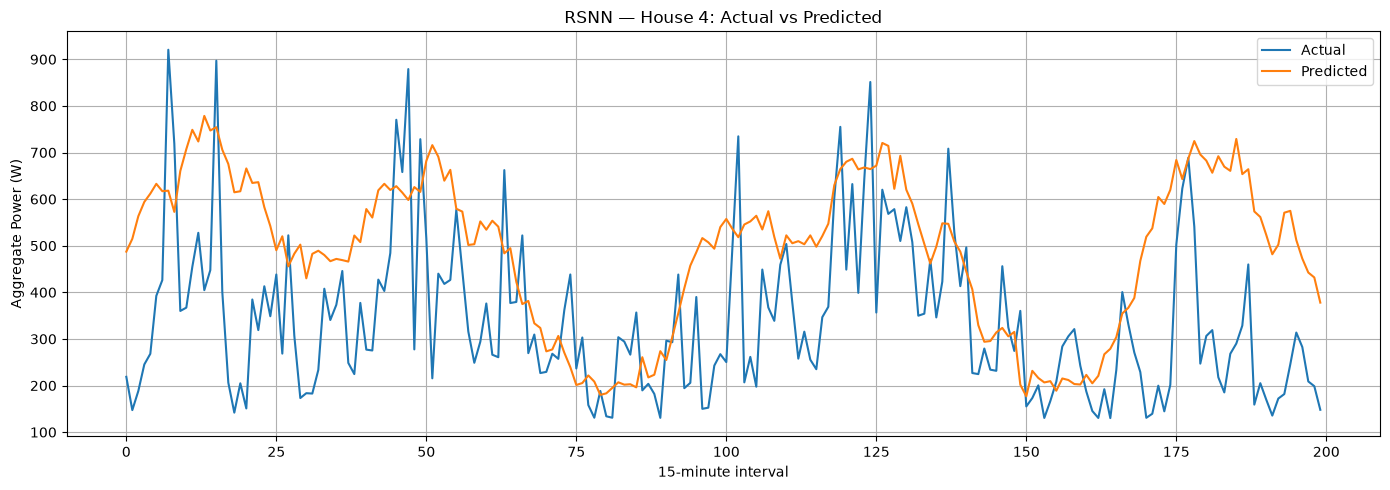

In [20]:
model.eval()
pred_scaled = []
actual_scaled = []

with torch.no_grad():
    for xb, yb, _ in test_loader:
        pred_scaled.append(model(xb.to(DEVICE)).cpu().numpy())
        actual_scaled.append(yb.numpy())

pred_scaled = np.concatenate(pred_scaled).reshape(-1, 1)
actual_scaled = np.concatenate(actual_scaled).reshape(-1, 1)

pred_watts = target_scaler.inverse_transform(pred_scaled).ravel()
actual_watts = target_scaler.inverse_transform(actual_scaled).ravel()

peak_threshold_watts = np.quantile(actual_watts, 0.90)
peak_mask = actual_watts >= peak_threshold_watts

mae = mean_absolute_error(actual_watts, pred_watts)
rmse = np.sqrt(mean_squared_error(actual_watts, pred_watts))
r2 = r2_score(actual_watts, pred_watts)
peak_mae = mean_absolute_error(actual_watts[peak_mask], pred_watts[peak_mask])
peak_rmse = np.sqrt(mean_squared_error(actual_watts[peak_mask], pred_watts[peak_mask]))
actual_max = actual_watts.max()
pred_max = pred_watts.max()
peak_ratio = pred_max / actual_max if actual_max > 0 else np.nan
peak_bias = np.mean(pred_watts[peak_mask] - actual_watts[peak_mask])

print("MAE:", f"{mae:.2f} W")
print("RMSE:", f"{rmse:.2f} W")
print("R2:", f"{r2:.4f}")
print("Peak MAE:", f"{peak_mae:.2f} W")
print("Peak RMSE:", f"{peak_rmse:.2f} W")
print("Peak bias:", f"{peak_bias:.2f} W")
print("Actual max:", f"{actual_max:.2f} W")
print("Predicted max:", f"{pred_max:.2f} W")
print("Peak amplitude ratio:", f"{peak_ratio:.4f}")

plt.figure(figsize=(14, 5))
points = min(200, len(actual_watts))
plt.plot(actual_watts[:points], label="Actual")
plt.plot(pred_watts[:points], label="Predicted")
plt.xlabel("15-minute interval")
plt.ylabel("Aggregate Power (W)")
plt.title("RSNN — House 4: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


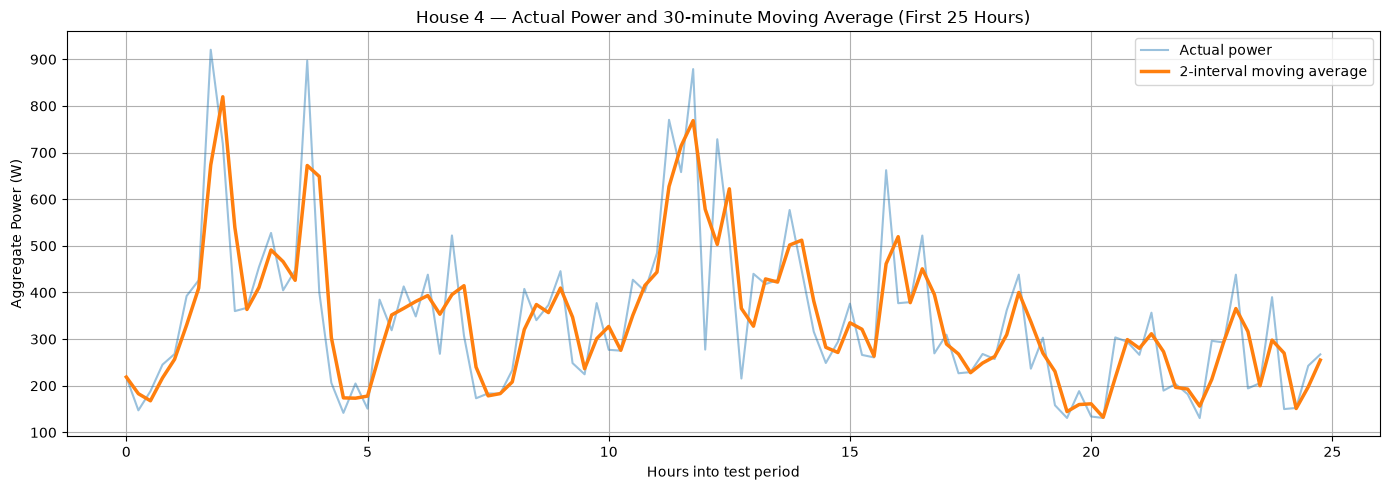

In [23]:
# Moving-average diagnostic for a shorter section of the test signal.
MOVING_AVERAGE_WINDOW = 2  # 2 x 15 minutes = 30 minutes
PLOT_POINTS = 100           # 100 x 15 minutes = 25 hours

actual_series = pd.Series(actual_watts)
actual_moving_average = actual_series.rolling(
    window=MOVING_AVERAGE_WINDOW,
    min_periods=1
).mean().to_numpy()

points = min(PLOT_POINTS, len(actual_watts))
time_axis = np.arange(points) * 15 / 60

plt.figure(figsize=(14, 5))
plt.plot(
    time_axis,
    actual_watts[:points],
    label="Actual power",
    alpha=0.45
)
plt.plot(
    time_axis,
    actual_moving_average[:points],
    label=f"{MOVING_AVERAGE_WINDOW}-interval moving average",
    linewidth=2.5
)
plt.xlabel("Hours into test period")
plt.ylabel("Aggregate Power (W)")
plt.title("House 4 — Actual Power and 30-minute Moving Average (First 25 Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
